# VASICEK SHORT RATE MODEL: CLOSED-FORM PRICES AND DISTRIBUTION CHECK
<a id="0"></a> <br>
The Vasicek model is one of the oldest and simplest models of the short interest rate. This notebook validates the Vasicek implementation in `vasicek.py`. The first section uses the EIOPA Risk-Free-Rate (RFR) calibration to produce a term structure, which is used for the initial short rate. In the second section, a number of stochastic interest rate scenarios are generated. The remaining sections check that the simulated distribution of the short rate and the simulated prices of bonds and bond options match the closed-form solutions of the Vasicek model.

The model starts from the following differential equation:

$$ dr(t) = \gamma \big( \mu - r(t) \big) dt + \sigma dW(t) $$

Where:
 - t is time.
 - r(t) is the short rate at time t.
 - $\mu$ is the long-term mean of the short rate.
 - $\gamma$ is the mean reversion speed parameter.
 - $\sigma$ is the volatility parameter.
 - $W(t)$ is a standard Brownian motion.

The initial short rate $r(0) = f(0,0)$ is the instantaneous forward rate at time 0, implied by the price of a zero-coupon bond (ZCB) $P(0,t)$ issued at time 0 with maturity t and a notional amount of 1. **This is the only information taken from the term structure.** Unlike the Hull-White model, the parameters of the Vasicek model are constant, so the model cannot reproduce an arbitrary term structure. The prices implied by the scenarios are therefore validated against the closed-form Vasicek prices, and not against the input term structure.

### Exact simulation scheme

The short rate can be written as a deterministic part plus a stochastic part:

$$ r(t) = m(t) + x(t), \qquad m(t) = \mu + \big(r(0) - \mu\big) e^{-\gamma t}, \qquad dx(t) = -\gamma x(t) dt + \sigma dW(t), \quad x(0) = 0 $$

The implementation simulates $x(t)$ and its integral $Y(t) = \int_0^t x(s) ds$ exactly on the time grid $t_0 = 0 < t_1 < \dots < t_N = T$. Given $x(t_{i-1})$, the pair $\big(x(t_i), Y(t_i) - Y(t_{i-1})\big)$ is normally distributed with known mean and covariance, and is sampled with two independent standard normal draws. The discount factor is:

$$ D(t) = e^{-\int_0^t r(s) ds} = \exp\Big( -\mu t - \big(r(0) - \mu\big)\frac{1 - e^{-\gamma t}}{\gamma} - Y(t) \Big) $$

The scheme has no discretisation error for any time step (see P. Glasserman (2003), *Monte Carlo Methods in Financial Engineering*, Springer, section 3.3 "Gaussian Short Rate Models").

### Summary

The goal of this script is to answer the following questions:
 - Does the term structure used for the initial short rate reproduce the curve published by EIOPA?
 - Is the Vasicek simulation correctly implemented?
 - Do the simulated discount factors reproduce the closed-form Vasicek bond prices?
 - Does the simulated distribution of the short rate match the closed-form distribution implied by the parameters?
 - Do the scenarios reproduce the closed-form prices of future bonds and bond options?
 - How far are the Vasicek bond prices from the input term structure?
 - Is the number of scenarios sufficiently large?

# Table of Contents
1. [Note on Smith & Wilson algorithm](#1)
2. [Success criteria](#2)
3. [Data requirements](#3)
4. [Vasicek parameters](#4)
5. [External dependencies](#5)
6. [Importing data](#6)
7. [Vasicek simulation](#7)
8. [Test 1; Term structure compared to the EIOPA published curve](#8)
9. [Test 2; Deterministic checks](#9)
10. [Test 3; Bond prices compared to the closed-form Vasicek prices](#10)
11. [Test 4; Distribution of the short rate](#11)
12. [Test 5; Prices of future bonds and bond options](#12)
13. [Comparison with the input term structure](#13)
14. [Number of scenarios](#14)
15. [Conclusion](#15)

<a id="1"></a> <br>
## Note on Smith & Wilson algorithm

The validation of RFR rate is performed in another script that checks the correct calibration of the EIOPA's RFR output, also available on OSM Github as a [Jupyter notebook](https://github.com/open-source-modelling/insurance_jupyter/tree/main/enough_stochastic_scenarios).

This example uses a modified Smith&Wilson implementation (The original implementation is availible on [GitHub](https://github.com/open-source-modelling):
-  [Python](https://github.com/open-source-modelling/insurance_python/tree/main/smith%26wilson)
-  [Matlab](https://github.com/open-source-modelling/insurance_matlab/tree/main/smith%26wilson)
-  [JavaScript](https://github.com/open-source-modelling/insurance_javascript/tree/main/smith-wilson)

#### Limitations of the implementation
The initial short rate is approximated with a centered finite difference with step `epsilon`. The script simplifies the day-count convention with the assumption that each month represents 1/12-th of a year. At every time step, the normal draws are rescaled to have a sample mean of 0 and a sample standard deviation of 1 (moment matching). This reduces the Monte Carlo noise, but it also means that some statistics (for example the mean of the short rate) are reproduced exactly by construction.

The parameters of the model are not calibrated to the term structure. Only a single EIOPA curve is used (No volatility adjustment).

<a id="2"></a> <br>
## Success criteria

The following success criteria is defined:
-  Test 1: Maximum difference between the Smith & Wilson spot rates and the EIOPA published spot rates is less than 0.1 bps and the average difference is less than 0.05 bps.
-  Test 2: With $\sigma = 0$, the short rate is equal to $m(t)$ and the discount factor is equal to $\exp\big(-\int_0^t m(s) ds\big)$. For any $\sigma$, the index is equal to the inverse of the discount factor. All up to numerical precision.
-  Test 3: The average discount factor does not differ from the closed-form Vasicek bond price by more than the Monte Carlo noise. The maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.
-  Test 4: The mean of the short rate equals $m(t)$ up to numerical precision. For the variance, the maximum absolute z-score over all time steps is less than 4.5 and the average absolute z-score is less than 2.5.
-  Test 5: The Monte Carlo prices of future zero-coupon bonds and of zero-coupon bond options do not differ from the closed-form prices by more than the Monte Carlo noise. The maximum absolute z-score is less than 4.5 and the average absolute z-score is less than 2.5.

The z-score thresholds are the same as in the Black-Scholes and Hull-White validation notebooks. They were checked by running Tests 3 to 5 with 200 different random seeds (10000 paths, 600 steps, the parameters of this run). All 200 runs passed.

The tests complement each other. With the same seed:
 - The previous implementation, which integrated the short rate with the trapezoid rule, fails Test 2 (relative difference of 2.6e-6 in the discount factor).
 - A volatility 5% higher than the parameter fails Test 4 (maximum z-score 11 for the variance) and Test 5 (maximum z-score 4.8 for the option price).
 - A long-term mean 5 bps higher than the parameter fails Tests 2, 3 (maximum z-score 5.0) and 5 (maximum z-score 4.8 for the bond price).
 - A mean reversion speed 5% higher than the parameter fails Tests 2 and 4 (maximum z-score 6.0 for the variance).

In [1]:
term_structure_max_diff_in_bps = 0.1
term_structure_average_diff_in_bps = 0.05
numerical_precision = 1e-10
z_score_max = 4.5
z_score_average = 2.5

The success function that is called at the end of every check is the following (With the threasholds that are defined above).

In [2]:
def SuccessTest(TestStatistics, threshold_max, threshold_mean):
    out1 = False
    out2 = False
    if np.max(TestStatistics)<threshold_max:
        print("Test passed")
        out1 = True
    else:
        print("Test failed")

    if np.mean(TestStatistics)<threshold_mean:
        print("Test passed")
        out2 = True
    else:
        print("Test failed")
    return [out1, out2]

This implementation looks at two kinds of test statistics. The average deviation and the maximum deviation.

The average deviation is defined as:

<font size=4>
$$S_{AVERAGE} = \frac{1}{N} \sum_{t = 0}^T \left|x_{THEORETICAL}(t) - x_{EST}(t) \right|$$
</font> <br>

The maximum deviation is defined as:
<font size=4>
$$ S_{MAX} = \max_t \left| x_{THEORETICAL}(t) - x_{EST}(t) \right| $$
</font> <br>

Where `N` is the number of time increments and `T` is the maximum maturity.

For the Monte Carlo estimates in Tests 3 to 5, the deviation is expressed as a z-score, which is the deviation divided by the standard error of the estimate:

<font size=4>
$$ z(t) = \frac{x_{EST}(t) - x_{THEORETICAL}(t)}{SE(t)} $$
</font> <br>

Using the z-score takes into account that the Monte Carlo noise grows with the time horizon.

<a id="3"></a> <br>
## Data requirements

This script uses the EIOPA RFR publication stored in the folder `data`. The publication can be found on the [EIOPA RFR website](https://www.eiopa.europa.eu/tools-and-data/risk-free-interest-rate-term-structures_en).

 - `Param_no_VA.csv` contains, for each country, the observed maturities, the Smith & Wilson calibration vector and the additional parameters (`UFR` and `alpha`). It corresponds to the sheet *SW_Qb_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Qb_SW.xlsx*.
 - `Curves_no_VA.csv` contains the published spot rates for maturities 1 to 150 years. It corresponds to the sheet *RFR_spot_no_VA* in the EIOPA workbook *EIOPA_RFR_YYYYMMDD_Term_Structures.xlsx*.

<a id="4"></a> <br>
## Vasicek parameters

This script provides validation for a single run of the Vasicek model. The run specifications are stored in `Parameters.csv` in the folder `data`. The first cell also makes the model code in the folder `code` available to this notebook:

In [3]:
import os
import sys
import pandas as pd

# This notebook is stored in the folder "notebooks". The model code is in the folder "code"
# and the input files are in the folder "data".
repository_root = os.path.abspath("..")
data_folder = os.path.join(repository_root, "data")
sys.path.insert(0, os.path.join(repository_root, "code"))

param_raw = pd.read_csv(os.path.join(data_folder, "Parameters.csv"), sep=',', index_col=0)
display(param_raw)

,model,Type,NoOfPaths,NoOfSteps,T,a,sigma,epsilon,Country,selected_param_file,selected_curves_file,mu,gamma
Calibration_ID,,,,,,,,,,,,,
11,HW,I,10000,600,50,0.05,0.008,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
22,BS,I,10000,600,50,0.00,0.200,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.00,0.0
33,V,D,10000,600,50,0.00,0.020,0.01,Slovenia,Param_no_VA.csv,Curves_no_VA.csv,0.02,0.3


This script will look at the run with the calibration id that uses the Vasicek model:

In [4]:
calibration_id = 33

The random seed is fixed so that the results of this notebook are reproducible:

In [5]:
seed = 0

<a id="5"></a> <br>
## External dependencies

This script uses a set of well known Python packages that are commonly used in finance. Numpy for the mathematical operation and matrix multiplication, Pandas for its table manipulation functionality and Matplotlib for charts. The model itself is imported from the modules in this repository.

In [6]:
import math
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from read_input import read_model_input
from term_structure import calculate_zero_coupon_price, smith_wilson_extrapolate_yield_curve, calculate_instantaneous_forward_rate
from vasicek import calculate_vasicek_paths

In [7]:
print(f"The Numpy version is {np.__version__}.")
print(f"The Pandas version is {pd.__version__}.")
print(f"The Matplotlib version is {mpl.__version__}.")

The Numpy version is 2.4.4.
The Pandas version is 3.0.2.
The Matplotlib version is 3.11.2.


<a id="6"></a> <br>
## Importing data

The run parameters and the Smith & Wilson calibration for the selected country are read with the same function that the generator uses (`read_model_input`).

In [8]:
[modeling_parameters, curve_parameters] = read_model_input(calibration_id)
param_raw.loc[calibration_id]

model                                  V
Type                                   D
NoOfPaths                          10000
NoOfSteps                            600
T                                     50
a                                    0.0
sigma                               0.02
epsilon                             0.01
Country                         Slovenia
selected_param_file      Param_no_VA.csv
selected_curves_file    Curves_no_VA.csv
mu                                  0.02
gamma                                0.3
Name: 33, dtype: object

In [9]:
num_paths = modeling_parameters["num_paths"]  # Number of stochastic scenarios
num_steps = modeling_parameters["num_steps"]  # Number of equidistant discrete modelling points (50*12 = 600)
end_time = modeling_parameters["end_time"]    # Time horizon in years (A time horizon of 50 years; T=50)
mu = modeling_parameters["mu"]                # Vasicek long-term mean parameter mu
gamma = modeling_parameters["gamma"]          # Vasicek mean reversion speed parameter gamma
sigma = modeling_parameters["sigma"]          # Vasicek volatility parameter sigma
epsilon = modeling_parameters["tolerance"]    # Step size for the finite difference approximation of the initial short rate
country = param_raw.loc[calibration_id, "Country"]
print(f"Country: {country}, paths: {num_paths}, steps: {num_steps}, T: {end_time}, mu: {mu}, gamma: {gamma}, sigma: {sigma}, epsilon: {epsilon}")

Country: Slovenia, paths: 10000, steps: 600, T: 50, mu: 0.02, gamma: 0.3, sigma: 0.02, epsilon: 0.01


The term structure is a function that returns the price of a ZCB for any maturity, calculated with the Smith & Wilson algorithm:

In [10]:
zero_coupon_price = lambda t: calculate_zero_coupon_price(t, curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])
forward_rate = lambda t: calculate_instantaneous_forward_rate(t, zero_coupon_price, epsilon)

The EIOPA published spot rates for the same country:

In [11]:
curve_raw = pd.read_csv(os.path.join(data_folder, param_raw.loc[calibration_id, "selected_curves_file"]), sep=',', index_col=0)
published_maturities = curve_raw.index.values.astype(float)
published_spot_rates = curve_raw.loc[:, country].values.astype(float)

The closed-form Vasicek price of a ZCB with time to maturity $\tau$, given the short rate r, is:

$$ P_V(\tau, r) = A(\tau) e^{-B(\tau) r}, \qquad B(\tau) = \frac{1 - e^{-\gamma \tau}}{\gamma}, \qquad \ln A(\tau) = \big(B(\tau) - \tau\big)\Big(\mu - \frac{\sigma^2}{2\gamma^2}\Big) - \frac{\sigma^2}{4\gamma} B(\tau)^2 $$

In [12]:
def vasicek_bond_price(tau, r):
    B = (1 - np.exp(-gamma * tau)) / gamma
    ln_A = (B - tau) * (mu - sigma**2 / (2 * gamma**2)) - sigma**2 / (4 * gamma) * B**2
    return np.exp(ln_A - B * r)

<a id="7"></a> <br>
## Vasicek simulation

The scenarios are generated with the same function that the generator uses. The output contains the time grid, the short rate paths `R`, the discount factors `M` and the bank account `I`.

In [13]:
np.random.seed(seed)
paths = calculate_vasicek_paths(num_paths, num_steps, end_time, zero_coupon_price, mu, sigma, gamma, epsilon)
t = paths["time"]
R = paths["R"]
M = paths["M"]
I = paths["I"]
r0 = R[0, 0]
mean_short_rate = mu + (r0 - mu) * np.exp(-gamma * t)
vasicek_term_structure = vasicek_bond_price(t, r0)
print(f"Initial short rate r(0) = {r0:.5f}")

Initial short rate r(0) = 0.03472


***
<span style=color:black>
    <b>Simulated short rate</b>
</span>
<br>
<span style=color:black>
    Percentiles of the simulated paths compared to the mean of the short rate m(t) and the forward rate f(0,t) of the input term structure
</span>

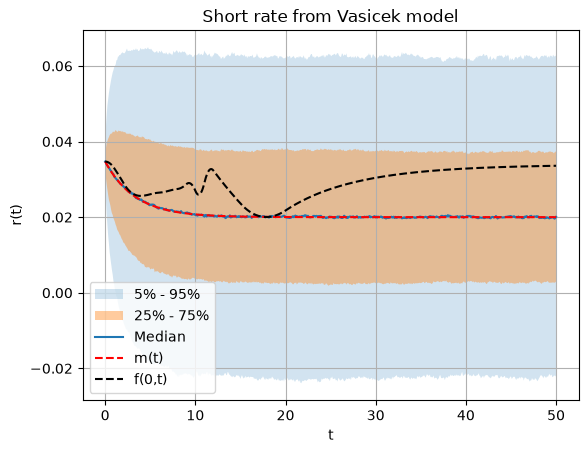

In [14]:
percentiles = np.percentile(R, [5, 25, 50, 75, 95], axis=0)
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t, percentiles[0], percentiles[4], alpha=0.2, label="5% - 95%")
ax1.fill_between(t, percentiles[1], percentiles[3], alpha=0.4, label="25% - 75%")
ax1.plot(t, percentiles[2], label="Median")
ax1.plot(t, mean_short_rate, "--r", label="m(t)")
ax1.plot(t, forward_rate(t), "--k", label="f(0,t)")
ax1.set_xlabel("t")
ax1.set_ylabel("r(t)")
ax1.set_title("Short rate from Vasicek model")
ax1.grid()
ax1.legend()
plt.show()

<a id="8"></a> <br>
## Test 1; Term structure compared to the EIOPA published curve

The initial short rate is taken from the term structure. This test recalculates the annually compounded spot rates with the Smith & Wilson algorithm used by the generator and compares them to the spot rates published by EIOPA for maturities 1 to 150 years.

In [15]:
calculated_spot_rates = smith_wilson_extrapolate_yield_curve(published_maturities.copy(), curve_parameters["target_maturities"], curve_parameters["calibration_vector"], curve_parameters["ultimate_forward_rate"], curve_parameters["convergence_speed"])
test_statistics_bdp_1 = pd.DataFrame(abs(calculated_spot_rates - published_spot_rates)*10000, index=published_maturities, columns=["Abs diff in bps"])
test_statistics_bdp_1.head()

,Abs diff in bps
1.0,0.000002
2.0,0.044901
3.0,0.002998
4.0,0.010952
5.0,0.011644


### Test 1; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [16]:
result1 = SuccessTest(test_statistics_bdp_1.values, term_structure_max_diff_in_bps, term_structure_average_diff_in_bps)

Test passed
Test passed


<a id="9"></a> <br>
## Test 2; Deterministic checks

Some properties of the output can be checked without any Monte Carlo noise:

 - If the volatility is set to $\sigma = 0$, the short rate is deterministic and decays from $r(0)$ towards $\mu$: $r(t) = m(t)$.
 - If the volatility is set to $\sigma = 0$, the discount factor is equal to $\exp\big(-\int_0^t m(s) ds\big) = \exp\big( -\mu t - (r(0) - \mu)(1 - e^{-\gamma t})/\gamma \big)$ for every path.
 - For any volatility, the bank account (output "I") is the inverse of the discount factor (output "D"), $I(t) D(t) = 1$.

The first two checks isolate the deterministic part of the model from the random part. They would detect a discretisation error in the integration of the short rate.

In [17]:
np.random.seed(seed)
paths_zero_vol = calculate_vasicek_paths(num_paths, num_steps, end_time, zero_coupon_price, mu, 0.0, gamma, epsilon)
deterministic_discount_factor = np.exp(-mu * t - (r0 - mu) * (1 - np.exp(-gamma * t)) / gamma)

test_statistics_2 = pd.DataFrame({
    "Max abs diff of short rate (sigma = 0)": [np.max(np.abs(paths_zero_vol["R"] - mean_short_rate))],
    "Max rel diff of discount factors (sigma = 0)": [np.max(np.abs(paths_zero_vol["M"] / deterministic_discount_factor - 1))],
    "Max abs diff of I * D": [np.max(np.abs(I * M - 1))]})
test_statistics_2

,Max abs diff of short rate (sigma = 0),Max rel diff of discount factors (sigma = 0),Max abs diff of I * D
0,0.0,0.0,1.110223e-16


### Test 2; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [18]:
result2 = SuccessTest(test_statistics_2.values, numerical_precision, numerical_precision)

Test passed
Test passed


<a id="10"></a> <br>
## Test 3; Bond prices compared to the closed-form Vasicek prices

The price of a ZCB implied by the scenarios must be equal to the closed-form Vasicek price:

$$ E\big[ D(t) \big] = P_V(t, r(0)) \qquad \text{for every } t $$

The simulated average is a Monte Carlo estimate, so it is compared to the closed-form price relative to its standard error:

$$ z(t) = \frac{\overline{D(t)} - P_V(t, r(0))}{\text{std}\big(D(t)\big) / \sqrt{n}} $$

Where n is the number of paths. Note that the closed-form Vasicek prices are different from the input term structure (see the section [Comparison with the input term structure](#13)).

In [19]:
sample_mean = np.mean(M, axis=0)[1:]
standard_error = np.std(M, axis=0, ddof=1)[1:] / np.sqrt(num_paths)
z_score_3 = (sample_mean - vasicek_term_structure[1:]) / standard_error
test_statistics_3 = pd.DataFrame(np.abs(z_score_3), index=t[1:], columns=["Abs z-score"])
test_statistics_3.describe()

,Abs z-score
count,600.000000
mean,0.084111
std,0.058468
min,0.000013
25%,0.043927
50%,0.076338
75%,0.109190
max,0.215061


***
<span style=color:black>
    <b>Closed-form and simulated price of a ZCB</b>
</span>
<br>
<span style=color:black>
    Monte Carlo estimate with a band of 3 standard errors
</span>

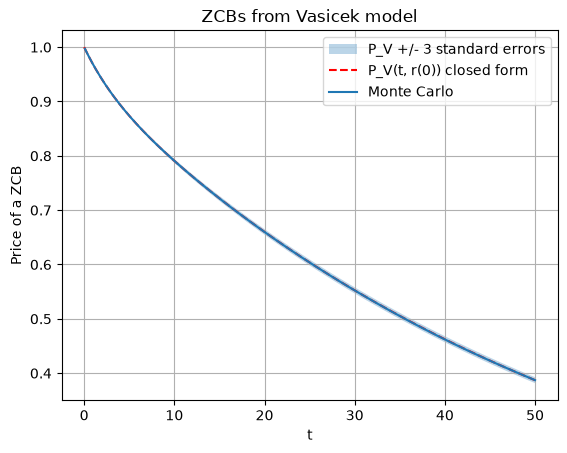

In [20]:
fig, ax1 = plt.subplots(1,1)
ax1.fill_between(t[1:], vasicek_term_structure[1:] - 3*standard_error, vasicek_term_structure[1:] + 3*standard_error, alpha=0.3, label="P_V +/- 3 standard errors")
ax1.plot(t, vasicek_term_structure, "--r", label="P_V(t, r(0)) closed form")
ax1.plot(t[1:], sample_mean, label="Monte Carlo")
ax1.set_xlabel("t")
ax1.set_ylabel("Price of a ZCB")
ax1.set_title("ZCBs from Vasicek model")
ax1.grid()
ax1.legend()
plt.show()

### Test 3; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [21]:
result3 = SuccessTest(test_statistics_3.values, z_score_max, z_score_average)

Test passed
Test passed


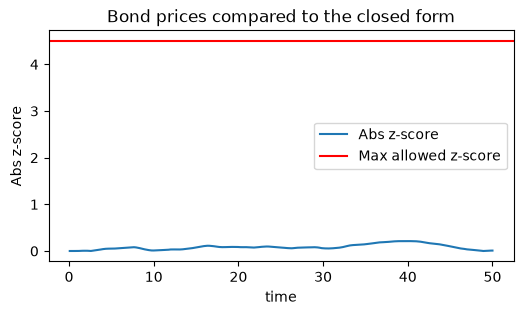

In [22]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_3, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Bond prices compared to the closed form')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="11"></a> <br>
## Test 4; Distribution of the short rate

The short rate of the Vasicek model is normally distributed:

$$ r(t) \sim N\Big( m(t), \; \frac{\sigma^2}{2\gamma}\big( 1-e^{-2\gamma t} \big) \Big), \qquad m(t) = \mu + \big(r(0) - \mu\big) e^{-\gamma t} $$

This test compares the simulated mean and variance of the short rate with these theoretical values. It checks that the parameters $\mu$, $\gamma$ and $\sigma$ are correctly implemented.

Because of the moment matching of the normal draws, the simulated mean is equal to the theoretical mean up to numerical precision. The simulated variance is a Monte Carlo estimate. It is compared to the theoretical variance relative to the standard error of the sample variance of a normal distribution, $V(t) \sqrt{2/(n-1)}$.

In [23]:
theoretical_mean = mean_short_rate[1:]
theoretical_variance = sigma**2/(2*gamma)*(1-np.exp(-2*gamma*t[1:]))

simulated_mean = np.mean(R, axis=0)[1:]
simulated_variance = np.var(R, axis=0, ddof=1)[1:]

z_score_4 = (simulated_variance - theoretical_variance) / (theoretical_variance * np.sqrt(2 / (num_paths - 1)))
test_statistics_4_mean = pd.DataFrame(np.abs(simulated_mean - theoretical_mean), index=t[1:], columns=["Abs diff of mean"])
test_statistics_4_variance = pd.DataFrame(np.abs(z_score_4), index=t[1:], columns=["Abs z-score of variance"])
pd.concat([test_statistics_4_mean, test_statistics_4_variance], axis=1).describe()

,Abs diff of mean,Abs z-score of variance
count,6.000000e+02,600.000000
mean,4.613786e-17,0.838260
std,3.522833e-17,0.572099
min,0.000000e+00,0.000405
25%,1.734723e-17,0.393562
50%,3.816392e-17,0.771901
75%,6.938894e-17,1.188175
max,1.804112e-16,3.000750


***
<span style=color:black>
    <b>Theoretical and simulated variance of the short rate</b>
</span>
<br>
<span style=color:black>
    Visual comparison
</span>

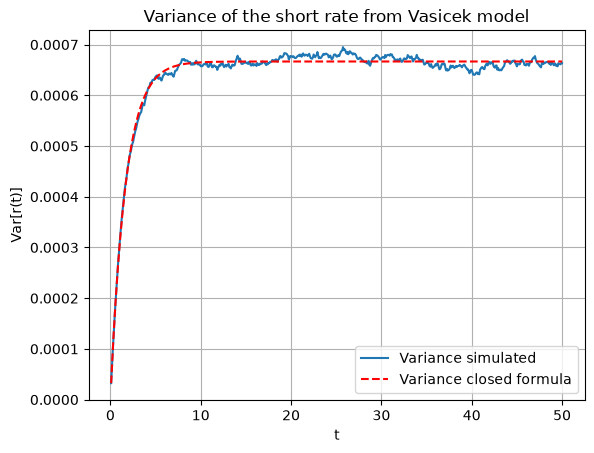

In [24]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], simulated_variance, label="Variance simulated")
ax1.plot(t[1:], theoretical_variance, "--r", label="Variance closed formula")
ax1.set_xlabel("t")
ax1.set_ylabel("Var[r(t)]")
ax1.set_title("Variance of the short rate from Vasicek model")
ax1.grid()
ax1.legend()
plt.show()

### Test 4; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [25]:
result4_mean = SuccessTest(test_statistics_4_mean.values, numerical_precision, numerical_precision)

Test passed
Test passed


In [26]:
result4_variance = SuccessTest(test_statistics_4_variance.values, z_score_max, z_score_average)

Test passed
Test passed


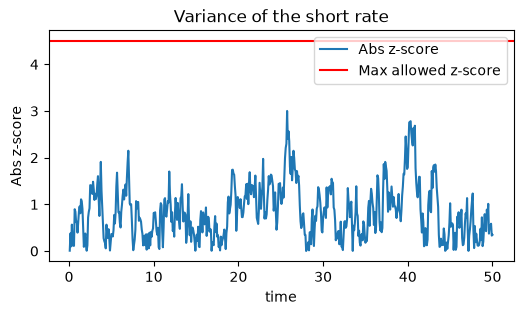

In [27]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t[1:], test_statistics_4_variance, label= "Abs z-score")
ax1.axhline(y = z_score_max, color = 'r', linestyle = '-',label="Max allowed z-score")
ax1.set_xlabel("time")
ax1.set_ylabel("Abs z-score")
ax1.set_title('Variance of the short rate')
ax1.legend()
fig.set_figwidth(6)
fig.set_figheight(3)
plt.show()

<a id="12"></a> <br>
## Test 5; Prices of future bonds and bond options

Tests 3 and 4 look at the discount factors and at the short rate separately. This test checks that they are consistent with each other, by pricing instruments that depend on both. The price at time S of a ZCB maturing at time T is $P_V(T-S, r(S))$.

**Future bond price.** The discounted future price of the bond must be equal to its price today:

$$ E\big[ D(S) P_V(T-S, r(S)) \big] = P_V(T, r(0)) $$

**Bond option.** The price of a European call option with expiry S and strike K on a ZCB maturing at T has the closed-form solution:

$$ ZBC(S,T,K) = P(0,T) N(h) - K P(0,S) N(h - \sigma_p), \qquad \sigma_p = \frac{\sigma}{\gamma}\big(1 - e^{-\gamma(T-S)}\big) \sqrt{\frac{1 - e^{-2\gamma S}}{2\gamma}}, \qquad h = \frac{1}{\sigma_p} \ln \frac{P(0,T)}{P(0,S) K} + \frac{\sigma_p}{2} $$

Where $P(0,S) = P_V(S, r(0))$, $P(0,T) = P_V(T, r(0))$ and N is the cumulative distribution function of the standard normal distribution. The Monte Carlo price is $E\big[ D(S) \max(P_V(T-S, r(S)) - K, 0) \big]$. The option price depends on the whole volatility structure of the model, which makes it the strongest single check of the implementation.

The test uses expiries S of 1 to 40 years, bonds with a maturity of T = S + 10 years and at-the-money forward strikes $K = P(0,T)/P(0,S)$.

In [28]:
normal_cdf = np.vectorize(lambda x: 0.5 * (1 + math.erf(x / math.sqrt(2))))

expiry = np.arange(1, 41).astype(float)
maturity = expiry + 10
expiry_index = np.round(expiry / end_time * num_steps).astype(int)

P0S = vasicek_bond_price(expiry, r0)
P0T = vasicek_bond_price(maturity, r0)
future_bond_price = vasicek_bond_price(maturity - expiry, R[:, expiry_index])
discount_to_expiry = M[:, expiry_index]

In [29]:
# Future bond price
discounted_bond = discount_to_expiry * future_bond_price
z_score_5_bond = (np.mean(discounted_bond, axis=0) - P0T) / (np.std(discounted_bond, axis=0, ddof=1) / np.sqrt(num_paths))

# Bond option
strike = P0T / P0S
sigma_p = sigma / gamma * (1 - np.exp(-gamma * (maturity - expiry))) * np.sqrt((1 - np.exp(-2 * gamma * expiry)) / (2 * gamma))
h = np.log(P0T / (P0S * strike)) / sigma_p + sigma_p / 2
option_closed_form = P0T * normal_cdf(h) - strike * P0S * normal_cdf(h - sigma_p)
discounted_payoff = discount_to_expiry * np.maximum(future_bond_price - strike, 0)
option_monte_carlo = np.mean(discounted_payoff, axis=0)
z_score_5_option = (option_monte_carlo - option_closed_form) / (np.std(discounted_payoff, axis=0, ddof=1) / np.sqrt(num_paths))

test_statistics_5_bond = pd.DataFrame(np.abs(z_score_5_bond), index=expiry, columns=["Abs z-score of bond price"])
test_statistics_5_option = pd.DataFrame(np.abs(z_score_5_option), index=expiry, columns=["Abs z-score of option price"])
pd.concat([test_statistics_5_bond, test_statistics_5_option], axis=1).describe()

,Abs z-score of bond price,Abs z-score of option price
count,40.000000,40.000000
mean,0.093796,0.494290
std,0.076626,0.311660
min,0.000838,0.009948
25%,0.034614,0.236923
50%,0.070461,0.496561
75%,0.159746,0.682932
max,0.260953,1.305591


***
<span style=color:black>
    <b>Closed-form and Monte Carlo price of a ZCB call option</b>
</span>
<br>
<span style=color:black>
    At-the-money options on a 10 year ZCB
</span>

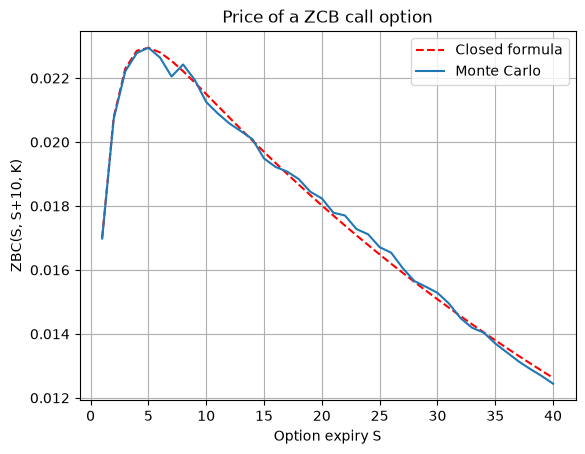

In [30]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(expiry, option_closed_form, "--r", label="Closed formula")
ax1.plot(expiry, option_monte_carlo, label="Monte Carlo")
ax1.set_xlabel("Option expiry S")
ax1.set_ylabel("ZBC(S, S+10, K)")
ax1.set_title("Price of a ZCB call option")
ax1.grid()
ax1.legend()
plt.show()

### Test 5; Success criteria

The successful application of the success criteria marks the completion/failiure of the test.

In [31]:
result5_bond = SuccessTest(test_statistics_5_bond.values, z_score_max, z_score_average)

Test passed
Test passed


In [32]:
result5_option = SuccessTest(test_statistics_5_option.values, z_score_max, z_score_average)

Test passed
Test passed


<a id="13"></a> <br>
## Comparison with the input term structure

The Vasicek model only takes the initial short rate from the term structure, so its bond prices differ from the input term structure. This section shows how large the difference is for the parameters of this run, expressed as the difference in continuously compounded yield:

$$ \Delta y(t) = -\frac{1}{t} \ln \frac{E\big[D(t)\big]}{P(0,t)} $$

A positive value means that the scenarios discount at a higher rate than the input term structure. This section is informative and has no success criteria. If the scenarios are used for market-consistent valuation, the Hull-White model, which reproduces the input term structure, should be used instead.

In [33]:
input_term_structure = zero_coupon_price(t)
yield_difference_in_bps = -np.log(sample_mean / input_term_structure[1:]) / t[1:] * 10000

selected_years = np.array([1, 5, 10, 20, 30, 40, 50])
selected_index = np.round(selected_years / end_time * num_steps).astype(int)
pd.DataFrame({"P(0,t) input": input_term_structure[selected_index],
              "E[D(t)] Vasicek": sample_mean[selected_index - 1],
              "Difference in bps of yield": yield_difference_in_bps[selected_index - 1]}, index=pd.Index(selected_years, name="Maturity"))

,"P(0,t) input",E[D(t)] Vasicek,Difference in bps of yield
Maturity,,,
1,0.966445,0.967868,-14.714412
5,0.865551,0.873695,-18.730008
10,0.755010,0.790740,-46.237716
20,0.589895,0.659825,-56.015444
30,0.450246,0.552287,-68.091572
40,0.327336,0.462021,-86.155914
50,0.234630,0.387124,-100.147084


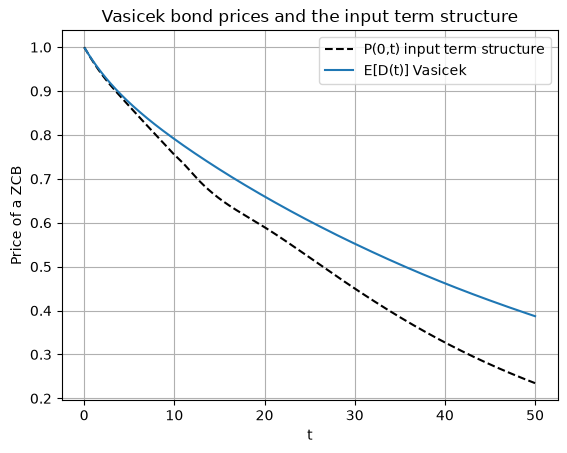

In [34]:
fig, ax1 = plt.subplots(1,1)
ax1.plot(t, input_term_structure, "--k", label="P(0,t) input term structure")
ax1.plot(t[1:], sample_mean, label="E[D(t)] Vasicek")
ax1.set_xlabel("t")
ax1.set_ylabel("Price of a ZCB")
ax1.set_title("Vasicek bond prices and the input term structure")
ax1.grid()
ax1.legend()
plt.show()

<a id="14"></a> <br>
## Number of scenarios

The z-scores in Tests 3 to 5 check that the differences are consistent with the Monte Carlo noise, but not whether the noise itself is small enough for the intended use. This section reports the size of the noise for the number of paths used in this run.

The table shows the relative standard error of the average discount factor, expressed in bps of yield ($SE / (P_V(t) \cdot t)$), and the number of paths needed so that three standard errors correspond to less than 1 bp of yield. The standard error is estimated without moment matching, so it is a conservative estimate. The moment matching reduces the actual error, which is shown in the last column for this run. This section is informative and has no success criteria.

In [35]:
relative_standard_error = standard_error[selected_index - 1] / vasicek_term_structure[selected_index]
standard_error_in_bps_of_yield = relative_standard_error / selected_years * 10000
paths_needed = np.ceil(num_paths * (3 * standard_error_in_bps_of_yield / 1.0)**2).astype(int)
actual_difference_in_bps_of_yield = np.abs(sample_mean[selected_index - 1] / vasicek_term_structure[selected_index] - 1) / selected_years * 10000
pd.DataFrame({"Standard error in bps of yield": standard_error_in_bps_of_yield,
              "Paths needed for 3 SE < 1 bp": paths_needed,
              "Actual difference in bps of yield": actual_difference_in_bps_of_yield}, index=pd.Index(selected_years, name="Maturity"))

,Standard error in bps of yield,Paths needed for 3 SE < 1 bp,Actual difference in bps of yield
Maturity,,,
1,1.036056,96608,0.000850
5,1.573071,222710,0.078637
10,1.549771,216162,0.016986
20,1.308241,154035,0.110592
30,1.139621,116887,0.066585
40,1.015528,92817,0.217771
50,0.938975,79351,0.008343


<a id="15"></a> <br>
## Conclusion

The tests are successful if the Vasicek interest rate generator passes all the success criteria. Based on the performed tests, if all the tests pass, it is likely that the implementation was generated using a correct methodology and ran using the correct parameters.

Passing the tests does not mean that the scenarios are market consistent. The Vasicek bond prices differ from the input term structure, as shown in the section [Comparison with the input term structure](#13).

In [36]:
pd.DataFrame(data = [result1, result2, result3, result4_mean, result4_variance, result5_bond, result5_option], columns = ["Max test","Mean test"],  \
             index= ["Term structure vs EIOPA", "Deterministic checks", "Bond prices vs closed form", "Mean of short rate", "Variance of short rate", "Future bond price", "Bond option price"])

,Max test,Mean test
Term structure vs EIOPA,True,True
Deterministic checks,True,True
Bond prices vs closed form,True,True
Mean of short rate,True,True
Variance of short rate,True,True
Future bond price,True,True
Bond option price,True,True
